# Decoder-Only Transformer

Because we are using a Decoder-Only Transformer, the inputs contain the questions (**"what is statquest?"** and **"statquest is what?"**) followed by an <EOS> token followed by the response, **"awesome"**. 

This is because all of those tokens will be used as inputs to the **Decoder-Only Transformer** during Training. 

<span style="color: red;"> **NOTE** All the diagrams used in this notebook and codes are from the stateQuest repo [StatQuest: Coding Transformers from Scratch!!!](https://github.com/StatQuest/decoder_transformer_from_scratch/blob/main/decoder_transformers_with_pytorch_and_lightning_v2.ipynb) and [youtube video](https://www.youtube.com/watch?v=C9QSpl5nmrY).</span>

<span style="color: red;">Thank StatQuest! </span>

![decoder-only_transformer](./images/decoder-only_diagram.png)


In [2]:
!pip install lightning

  Using cached torch-2.11.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp311-cp311-macosx_11_0_arm64.whl (80.5 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.0.0
    Uninstalling torch-2.0.0:
      Successfully uninstalled torch-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtext 0.15.1 requires torch==2.0.0, but you have torch 2.11.0 which is incompatible.
torchdata 0.6.0 requires torch==2.0.0, but you have torch 2.11.0 which is incompatible.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import lightning as L

from IPython.display import Image, display

In [2]:
token_to_id = {'what' : 0,
               'is' : 1,
               'statquest' : 2,
               'awesome': 3,
               '<EOS>' : 4, ## <EOS> = end of sequence
              }

id_to_token = dict(map(reversed, token_to_id.items()))
id_to_token

{0: 'what', 1: 'is', 2: 'statquest', 3: 'awesome', 4: '<EOS>'}

In [3]:
inputs = torch.tensor(
    [
        [   # input #1: what is statquest <EOS> awesome
            token_to_id["what"],
            token_to_id["is"], 
            token_to_id["statquest"], 
            token_to_id["<EOS>"],
            token_to_id["awesome"]
        ], 
        [   # input #2: statquest is what <EOS> awesome
            token_to_id["statquest"],
            token_to_id["is"], 
            token_to_id["what"], 
            token_to_id["<EOS>"], 
            token_to_id["awesome"]
        ]
    ]
)
print(inputs)

labels = torch.tensor(
    [
        [
            token_to_id["is"], 
            token_to_id["statquest"], 
            token_to_id["<EOS>"], 
            token_to_id["awesome"], 
            token_to_id["<EOS>"]
        ],  
                       
        [
            token_to_id["is"], 
            token_to_id["what"], 
            token_to_id["<EOS>"], 
            token_to_id["awesome"], 
            token_to_id["<EOS>"]
        ]
    ]
)
print(labels) # labels are the next token from inputs

dataset = TensorDataset(inputs, labels) 
dataloader = DataLoader(dataset)

tensor([[0, 1, 2, 4, 3],
        [2, 1, 0, 4, 3]])
tensor([[1, 2, 4, 3, 4],
        [1, 0, 4, 3, 4]])


## Word Emebedding

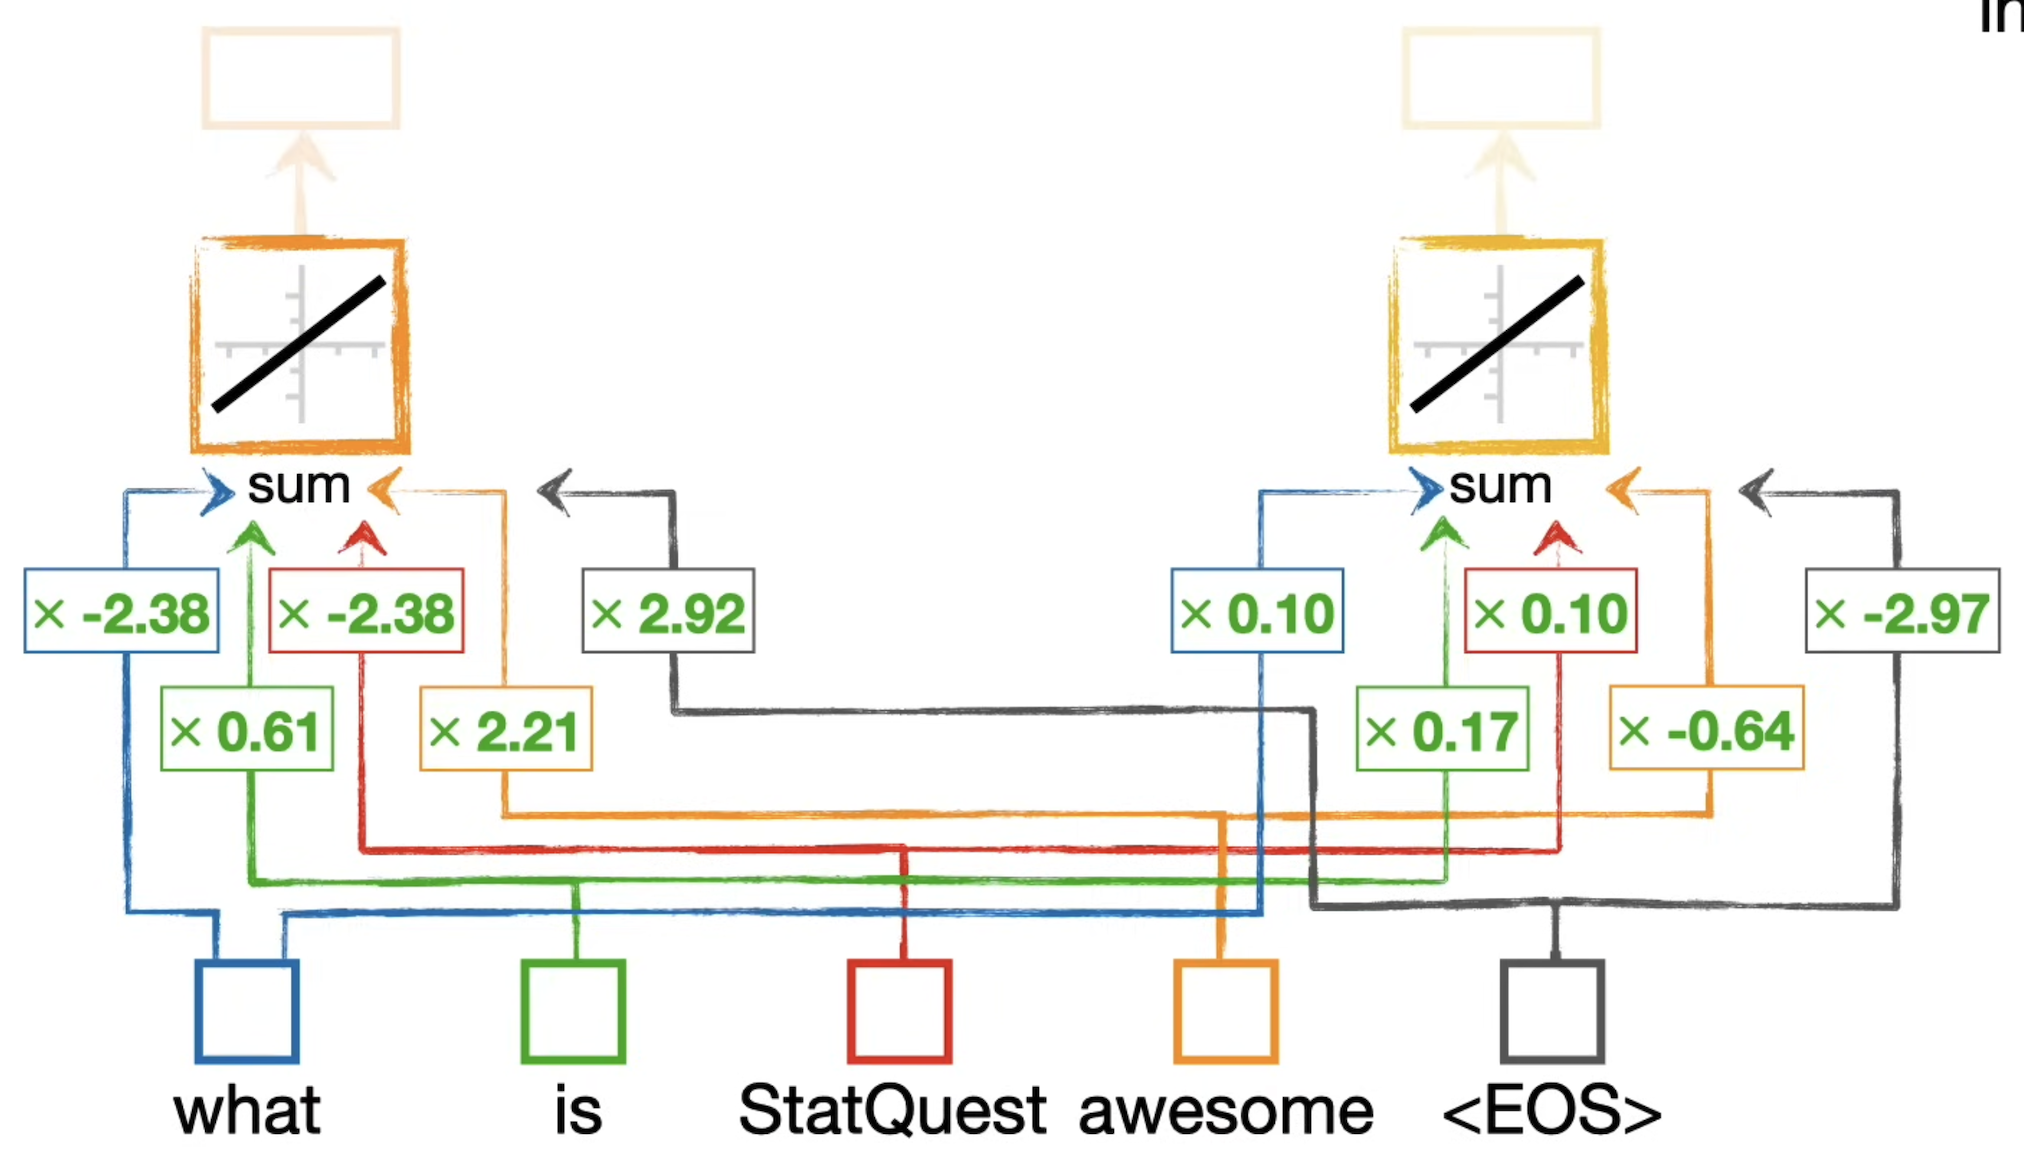

In [8]:
display(Image(filename='./images/word_embedding.png', width=800))

The word emebedding matrix is (assuming embedding dim = 2)


$$
M_{we} = \begin{pmatrix}
\textrm{"what"} & textrm{"is"} & \textrm{"StatQuest"} & \textrm{"awesome"} & \textrm{"<EOS>"} \\
-2.38 & 0.61 & -2.38 & 2.21 & 2.92\\
0.1 & 0.17 & 0.1 & -0.64 & -2.97
\end{pmatrix}
$$

So inputs
$$
\begin{pmatrix}
\textrm{"what"} & 1 & 0 & 0 & 0 & 0\\
\textrm{"is"} & 0 & 1 & 0 & 0 & 0\\
\textrm{"StatQuest"} & 0 & 0 & 1 & 0 & 0 \\
 & \cdots &  & \cdots &  & \cdots
\end{pmatrix}
$$

The word embedding for each token is given by 

$$
\begin{pmatrix}
\textrm{"what"} & 1 & 0 & 0 & 0 & 0\\
\textrm{"is"} & 0 & 1 & 0 & 0 & 0\\
\textrm{"StatQuest"} & 0 & 0 & 1 & 0 & 0
\end{pmatrix} M^T_{we} = \begin{pmatrix}
\textrm{"what"} & -2.38 & 0.1 \\
\textrm{"is"} & 0.61 & 0.17 \\
\textrm{"StatQuest"} & -2.38 & 0.1
\end{pmatrix}
$$ 

## Position Encoding

The most commonly used method for position encodings are **sine**, **cosine** squiggles, given by 

$$ \textrm{PE}(pos, 2i) = \sin(pos/10000^{2i/d_{emb}}), $$ 
$$ \textrm{PE}(pos, 2i+1) = \cos(pos/10000^{2i/d_{emb}}).$$

The following diagram shows the first 4 embedding positions.

![positional_encoding](./images/pos_encoding.png)


Assume the embedding dimension is 4, so $d_{emb}=4$. For the word tokens "what" and "is", the embeddings are `[0.2, -0.1, 1,2, -0.4]` and `[1.1, 0.6, -1,3, 0.9]`, then we can calculate position encoding as follows:

| token | (token) pos |  embedding position | embedding value | i | PE |
| --- | --- | --- | --- | --- | --- |
| "what" | 0| 1st | 0.2  |  0 | $PE(0, 0) = sin(0/10000^{0/4}) = 0$|
| "what" | 0| 2nd | -0.1 |  0| $PE(0, 1) = cos(0/10000^{0/4}) = 1$|
| "what" | 0| 3rd |  1.2 |  1 | $PE(0, 2) = sin(0/10000^{2*1/4}) = 0$|
| "what" | 0| 4th  |  -0.4 |  1 | $PE(0, 3) = cos(0/10000^{2*1/4}) = 1$|
| "is" | 1| 1st | 1.1 | 0 | $PE(1, 0) = sin(1/10000^{0/4}) = 0.84$|
| "is" | 1| 2nd | 0.6 | 0 | $PE(1, 1) = cos(1/10000^{0/4}) = 0.54 $|
| "is" | 1| 3rd |  -1.3 |  1 |$PE(1, 2) = sin(1/10000^{2*1/4}) = 0.01$|
| "is" | 1| 4th | 0.9 |  1 | $PE(1, 3) = cos(1/10000^{2*1/4})$|

Following the "what is StatQuest" example, we have word embedding + positional encoding as

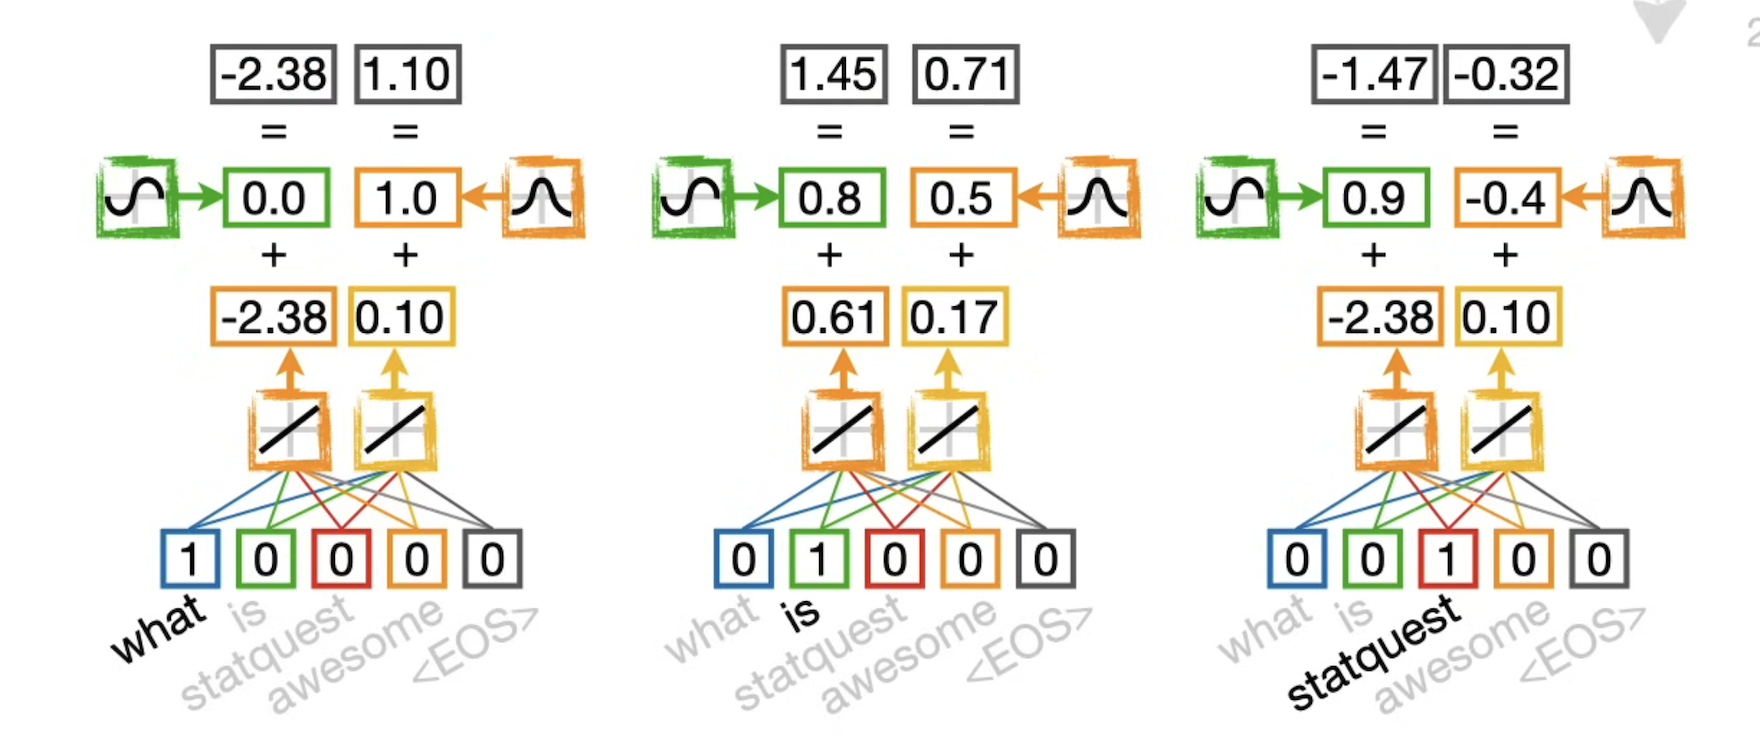

In [11]:
display(Image(filename='./images/pos_encoding_example.png', width=800))

In [21]:
class PositionEncoding(nn.Module):
    
    def __init__(self, d_model=2, max_len=6):
        """
        d_model = The dimension of the transformer, which is also the number of embedding values per token.
                  In the transformer I used in the StatQuest: Transformer Neural Networks Clearly Explained!!!
                  d_model=2, so that's what we'll use as a default for now.
                  However, in "Attention Is All You Need" d_model=512
        max_len = maximum number of tokens we allow as input.
                  Since we are precomputing the position encoding values and storing them in a lookup table
                  we can use d_model and max_len to determine the number of rows and columns in that
                  lookup table.
        
                  In this simple example, we are only using short phrases, so we are using
                  max_len=6 as the default setting.
                  However, in The Annotated Transformer, they set the default value for max_len to 5000

        positional encoding:
         * PE(pos, 2i)   = sin(pos/10000^{2i/d})
         * PE(pos, 2i+1) = cos(pos/10000^{2i/d})

         pos: token position (e.g. "what is StatQuest", pos["what"]=0)
         i: stands for embedding. (e.g. "what" word embedding = [0.2, -0.1, 1,2, -0.4], i = [0, 0, 2, 2]
        """
        
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(start=0, end=max_len, step=1).float().unsqueeze(1) # i, [0, 1, 2, 3....]
        embedding_index = torch.arange(start=0, end=d_model, step=2).float() # 2*i, [0, 2, 4, 6, ...]
       
        div_term = 1/torch.tensor(10000.0)**(embedding_index / d_model) # 1/10000^{2i/d} 
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # print on "pe" will look like Tensor([[0, 1],
        #                                     [0.84, 0.53],
        #                                     ...
        #                                    ])
        
        self.register_buffer('pe', pe) ## "register_buffer()" ensures that 'pe' will be moved to wherever the model gets
                                       ## moved to. So if the model is moved to a GPU, then, even though we don't need to optimize 'pe', 
                                       ## it will also be moved to that GPU. This, in turn, means that accessing 'pe' will be relatively 
                                       ## fast copared to having a GPU have to get the data from a CPU.

    def forward(self, word_embeddings):

        print(word_embeddings.shape, word_embeddings.size(0), self.pe[:word_embeddings.size(0), :].shape)
        
        return word_embeddings + self.pe[:word_embeddings.size(0), :] ## word_embeddings.size(0) = number of embeddings
                                                                      ## NOTE: That second ':' is optional and 
                                                                      ## we could re-write it like this: 
                                                                      ## self.pe[:word_embeddings.size(0)]


pos_encoding = PositionEncoding()
word_embedding = torch.tensor([[ 0.3367,  0.1288], [ 0.2345,  0.2303], [-1.1229, -0.1863], [ 0.4617,  0.2674]])
pos_encoding(word_embedding)

torch.Size([4, 2]) 4 torch.Size([4, 2])


tensor([[ 0.3367,  1.1288],
        [ 1.0760,  0.7706],
        [-0.2136, -0.6024],
        [ 0.6028, -0.7226]])

## Attention

### Self-attention

**Self-Attention** is a type of attention used in **Encoder-Decoder** and **Encoder-Only transformers**. It allows every word in a phrase to define a relationship with any other word in the phrase, regardless of the order of the words.

![self_attention](./images/self_attention.png)

$$Attention(Q, K, V) = SoftMax \Big( \frac{QK^T}{\sqrt{d_k}} \Big) V$$

### Masked self-attention

**Masked Self-Attention** is used by **Encoder-Decoder** and **Decoder-Only** transformers and it allows each word in a phrase to define a relationship with itself and the words that came before it. 

* In **Encoder-Decoder transformers**, Masked Self-Attention is used during training, when we know what the output should be, but we still force the decoder to generate it one token at a time, thus, limiting attention to only output words that came earlier.
* In contrast, **Decoder-Only transformers** use Masked Self-Attention all the time, on the input and the output, during training and inference.

![mask_self_attention](./images/masked_self_attention.png)

$$MaskedAttention(Q, K, V) = SoftMax \Big( \frac{QK^T}{\sqrt{d_k}} +M \Big) V$$


### Compute Attention

Given word embedding values for each word/token in the input phrase **"< SOS > let's go"** in matrix form, we multiply them by matrices of weights to create **Queries**, **Keys**, and **Values**.
The weight metrices $W_q$, $W_k$, $W_v$ corresponding to **W_q**, **W_k**, **W_v** in the subsequent code are **optimized** through backprogagtion during training the transformer.

In the following, we use embedding dim = 2.

#### Query 

![attention_compute_q](./images/attention_compute_q.png)

#### Key 
![attention_compute_k](./images/attention_compute_k.png)

#### Value
![attention_compute_v](./images/attention_compute_v.png)

#### Compute $(Q*K^T)$ and Rescale $(Q*K^T)/\sqrt{d}$

![attention_q_times_kt](./images/attention_q_times_kt.png)

Since embedding dim = 2, so $d=2$.

![attention_scaling_scores](./images/attention_scaling_scores.png)


#### Masked Self-Attention: $(Q*K^T)/\sqrt{d} + M$

![attention_masking](./images/attention_masking.png)


#### SoftMax on Self-Attention (Weights)

**NOTE** The output of the Softmax function are called **attention weights**. They are the "normalized" version of the raw similarity scores between tokens.

![attention_softmax](./images/attention_softmax.png)

#### SoftMax on Masked Self-Attention (Weights)

**NOTE** The output of the Softmax function are called **attention weights**. They are the "normalized" version of the raw similarity scores between tokens.

![attention_softmax_masked](./images/attention_softmax_masked.png)


#### Self-Attention Values

Now, attentions values are the attention weights multiplying values.

![attention_final_scores](./images/attention_final_scores.png)

#### Masked Self-Attention Values

Now, attentions values are the attention weights multiplying values.

![attention_final_scores_masked](./images/attention_final_scores_masked.png)



In [9]:
class Attention(nn.Module): 
    
    def __init__(self, d_model=2):
        """
        d_model = the number of embedding values per token.
        """
        
        super().__init__()
        
        self.d_model=d_model
        
        # Initialize the Weights (W) for query (q), key (k) and value (v) numbers for each token
        self.W_q = nn.Linear(in_features=d_model, out_features=d_model, bias=False)
        self.W_k = nn.Linear(in_features=d_model, out_features=d_model, bias=False)
        self.W_v = nn.Linear(in_features=d_model, out_features=d_model, bias=False)
        
        self.row_dim = 0
        self.col_dim = 1

        
    def forward(self, encodings_for_q, encodings_for_k, encodings_for_v, mask=None):
        """
        Create the query, key and values using the encodings associated with each token (token encodings)
        """
        q = self.W_q(encodings_for_q)
        k = self.W_k(encodings_for_k)
        v = self.W_v(encodings_for_v)

        sims = torch.matmul(q, k.transpose(dim0=self.row_dim, dim1=self.col_dim))  # (q * k^T)
        scaled_sims = sims / torch.tensor(k.size(self.col_dim)**0.5)               # (q * k^T)/sqrt(d_model)

        if mask is not None:
            scaled_sims = scaled_sims.masked_fill(mask=mask, value=-1e9) # (q * k^T)/sqrt(d_model) + M
        
        attention_percents = F.softmax(scaled_sims, dim=self.col_dim) # softmax((q * k^T)/sqrt(d_model) + M)

        # Scale the values by their associated percentages and add them up.
        attention_scores = torch.matmul(attention_percents, v) # softmax((q * k^T)/sqrt(d_model) + M) * V
        
        return attention_scores

## Residual Connections

Now we have residual connection values for each token:

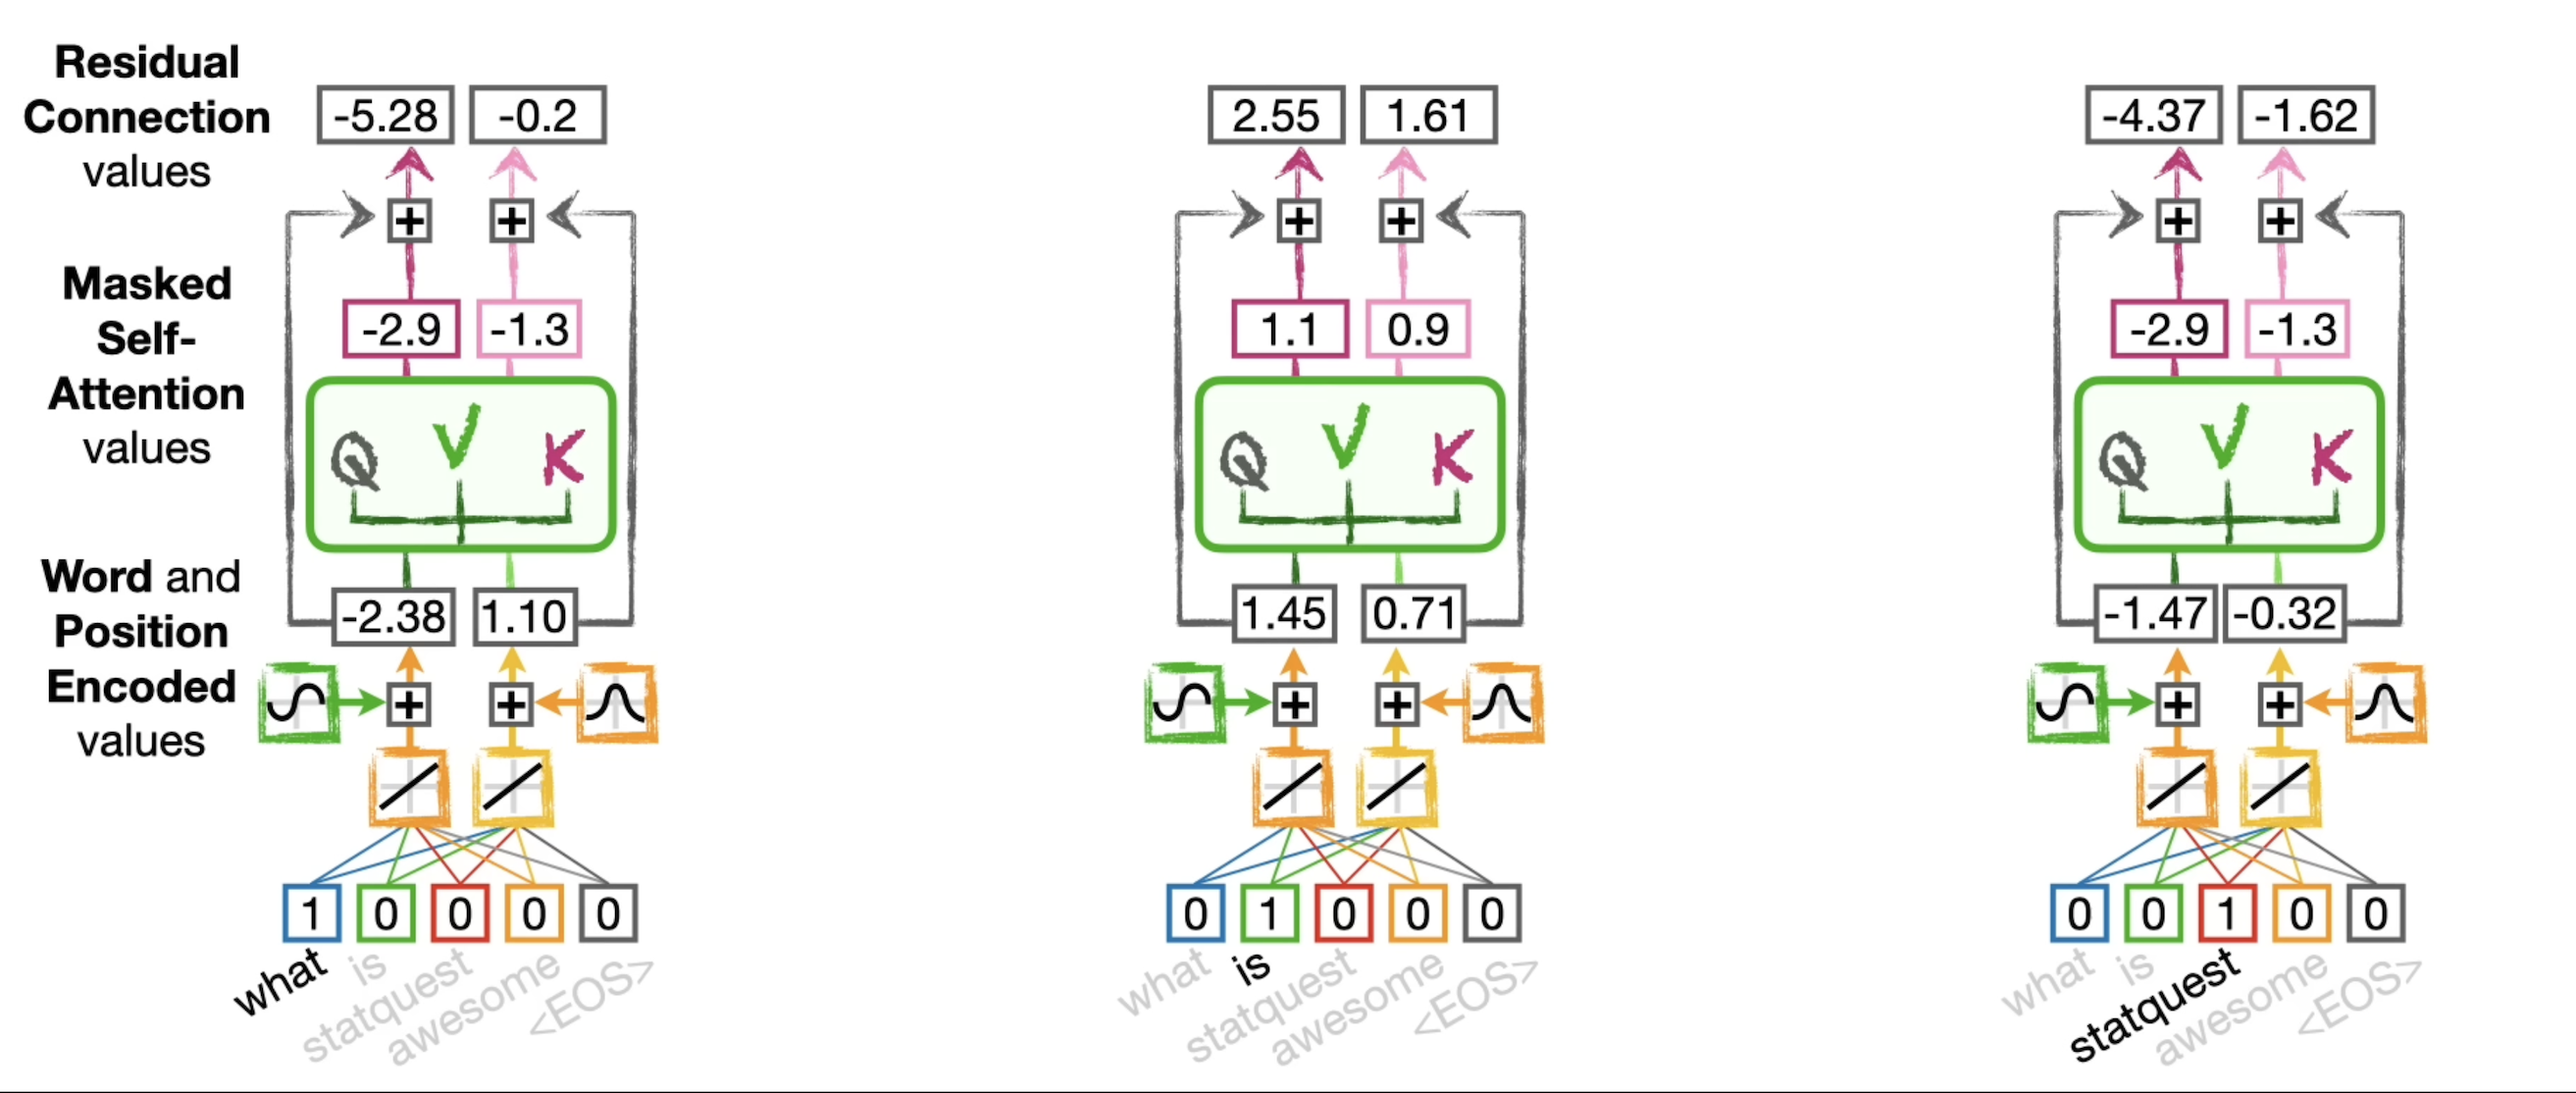

In [19]:
display(Image(filename='./images/resid_connection.png', width=1000))

## Fully Connected Networks and Predict Token

Input token is "what", then:

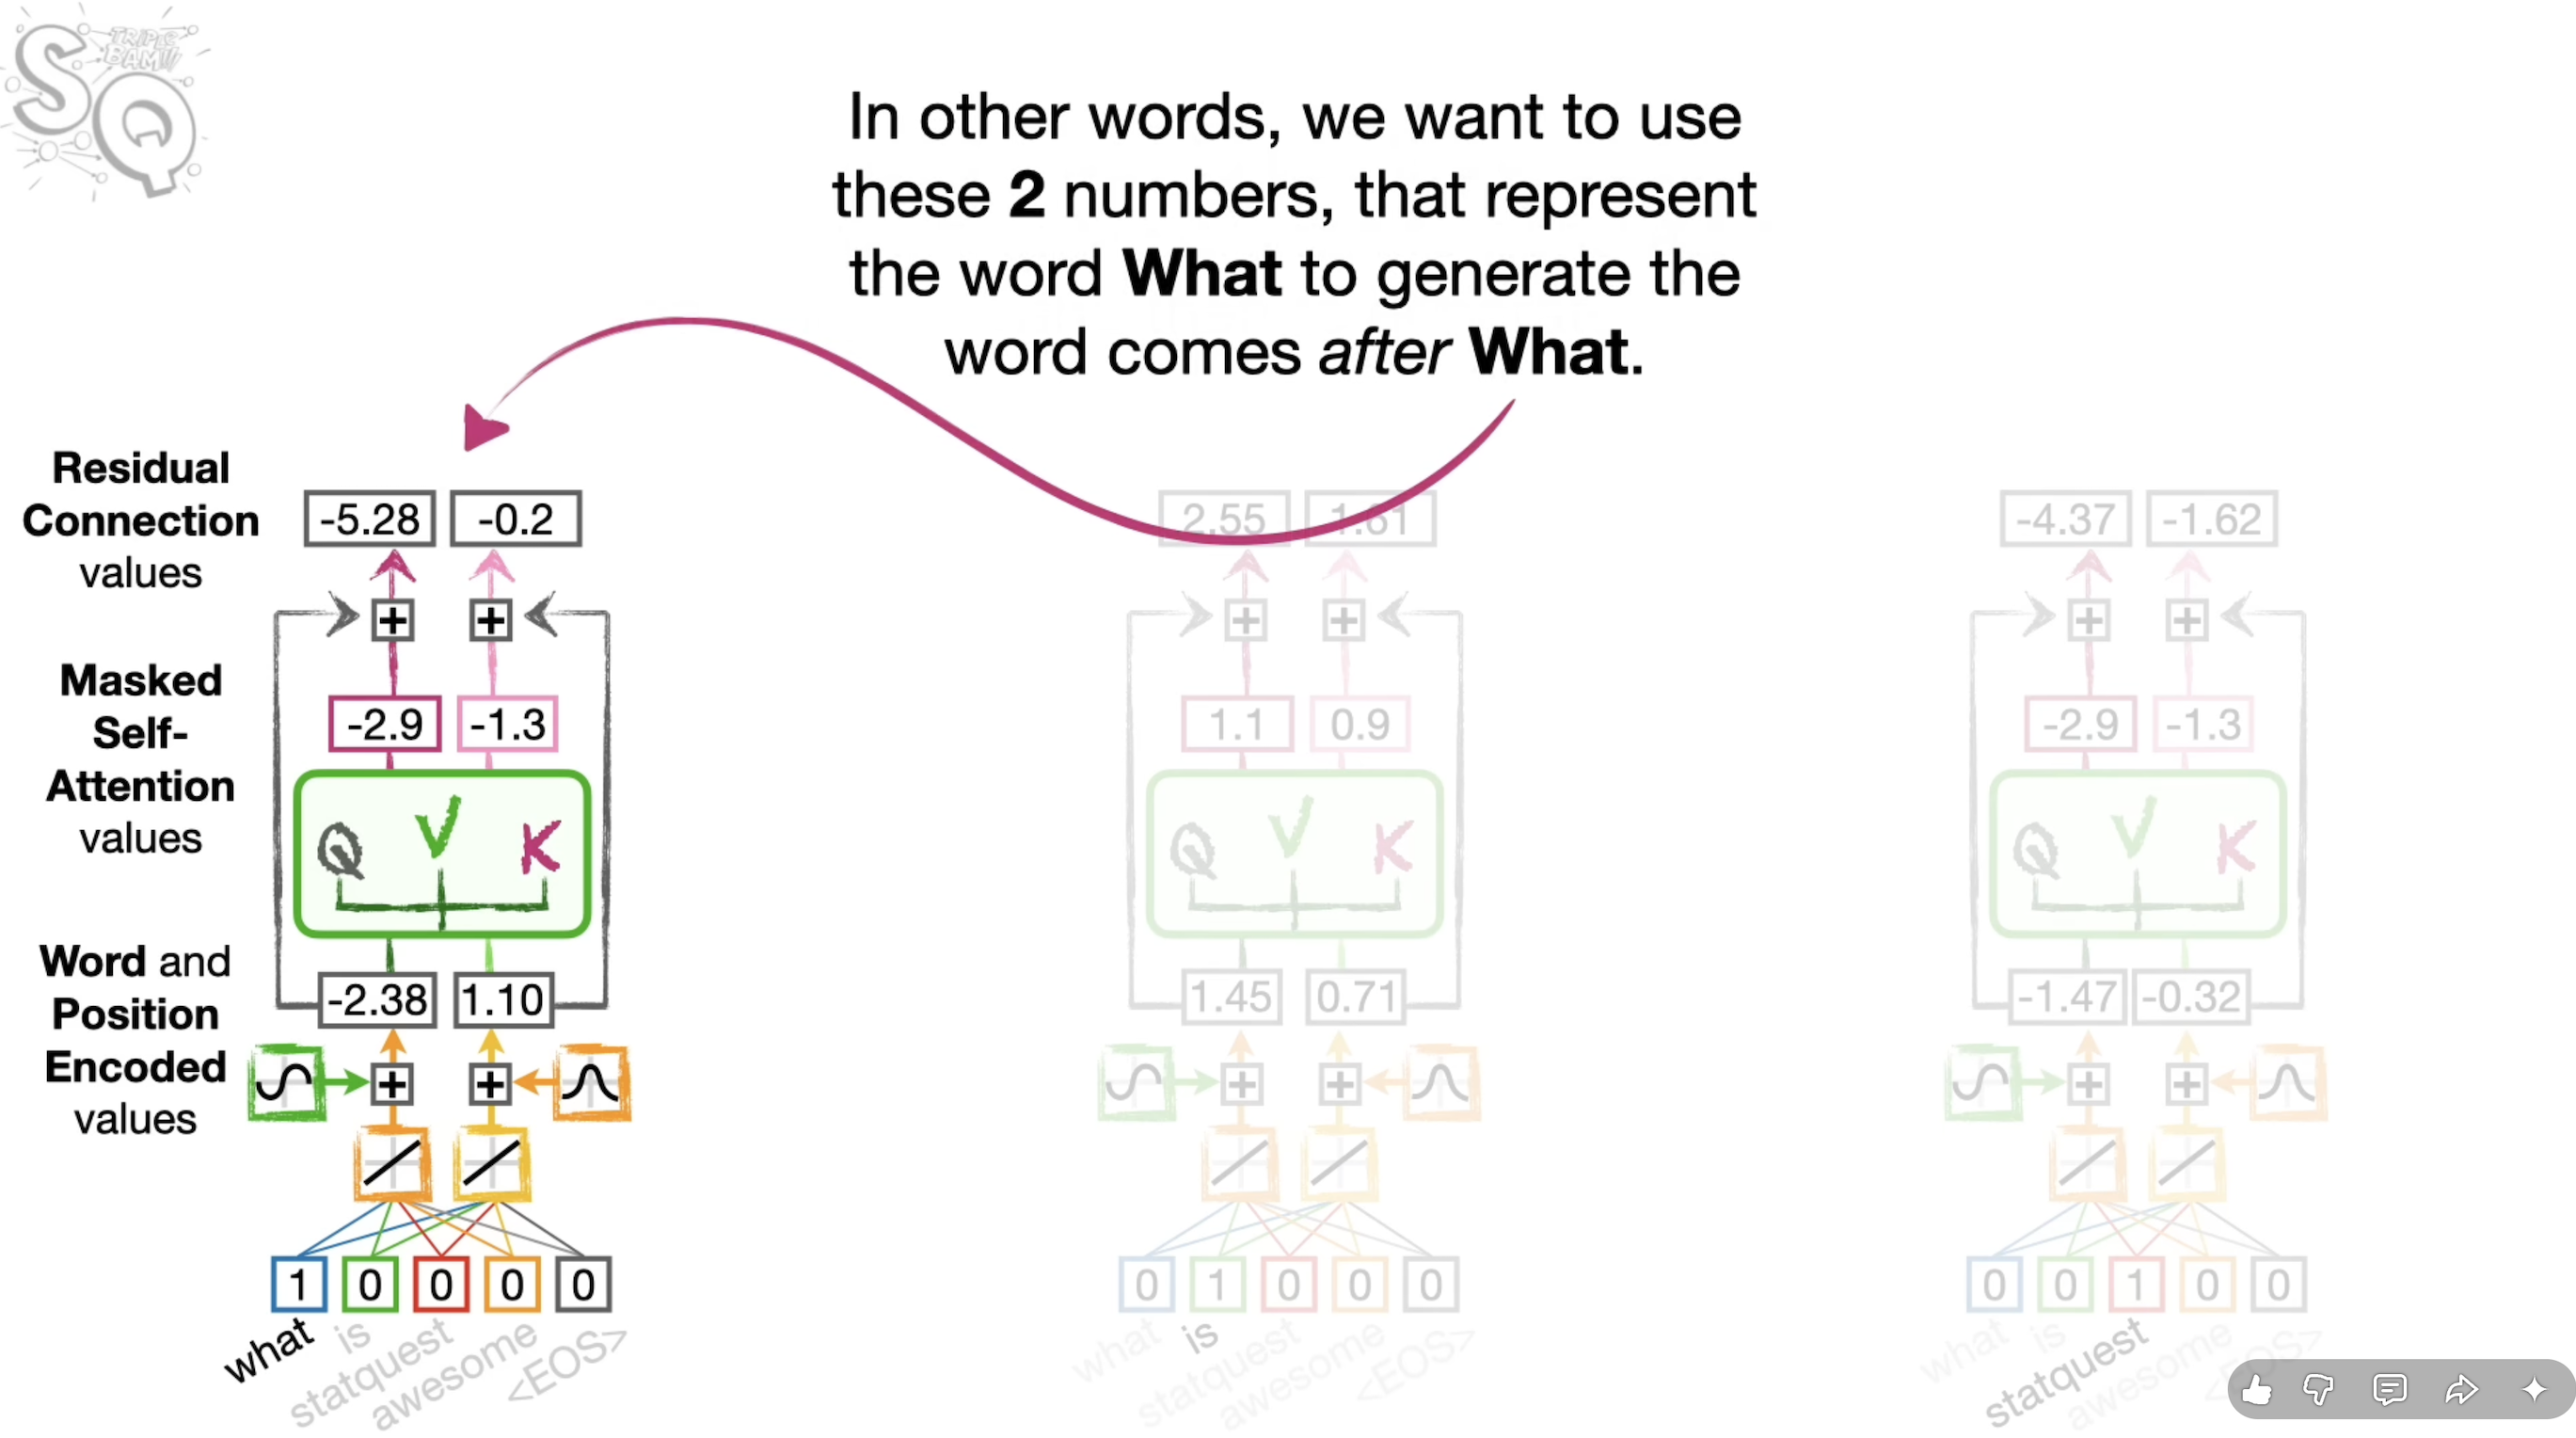

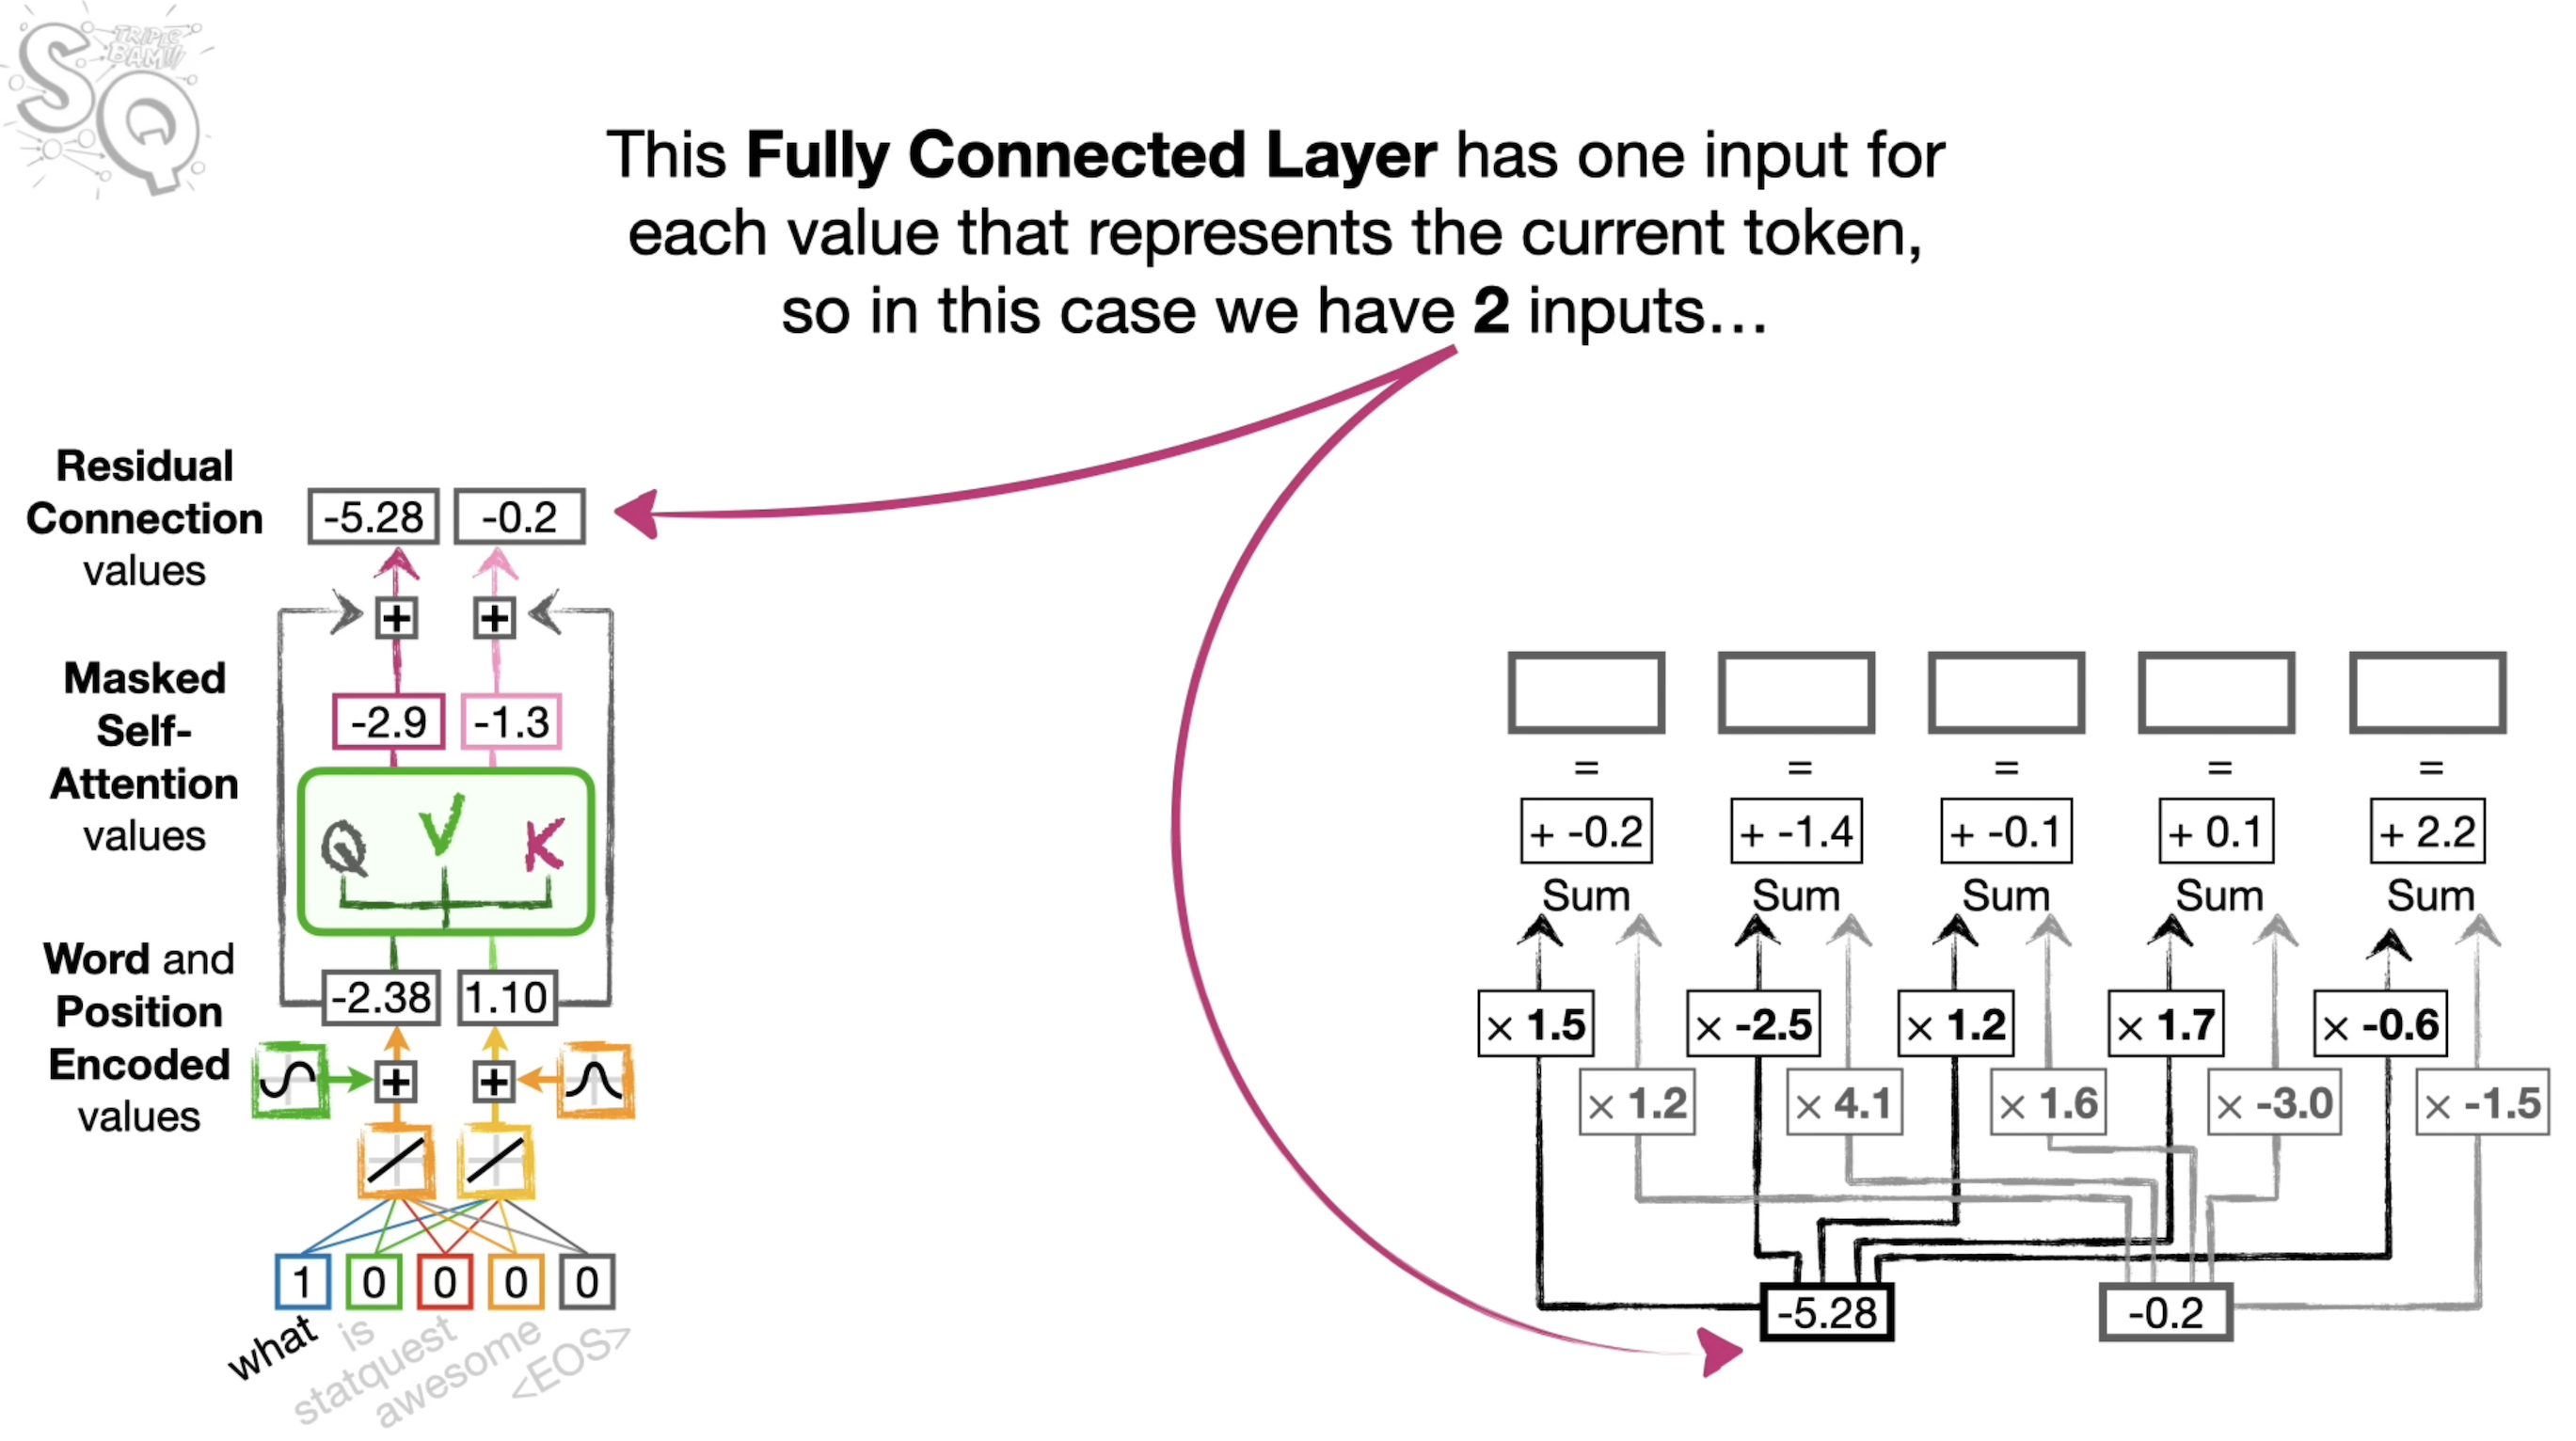

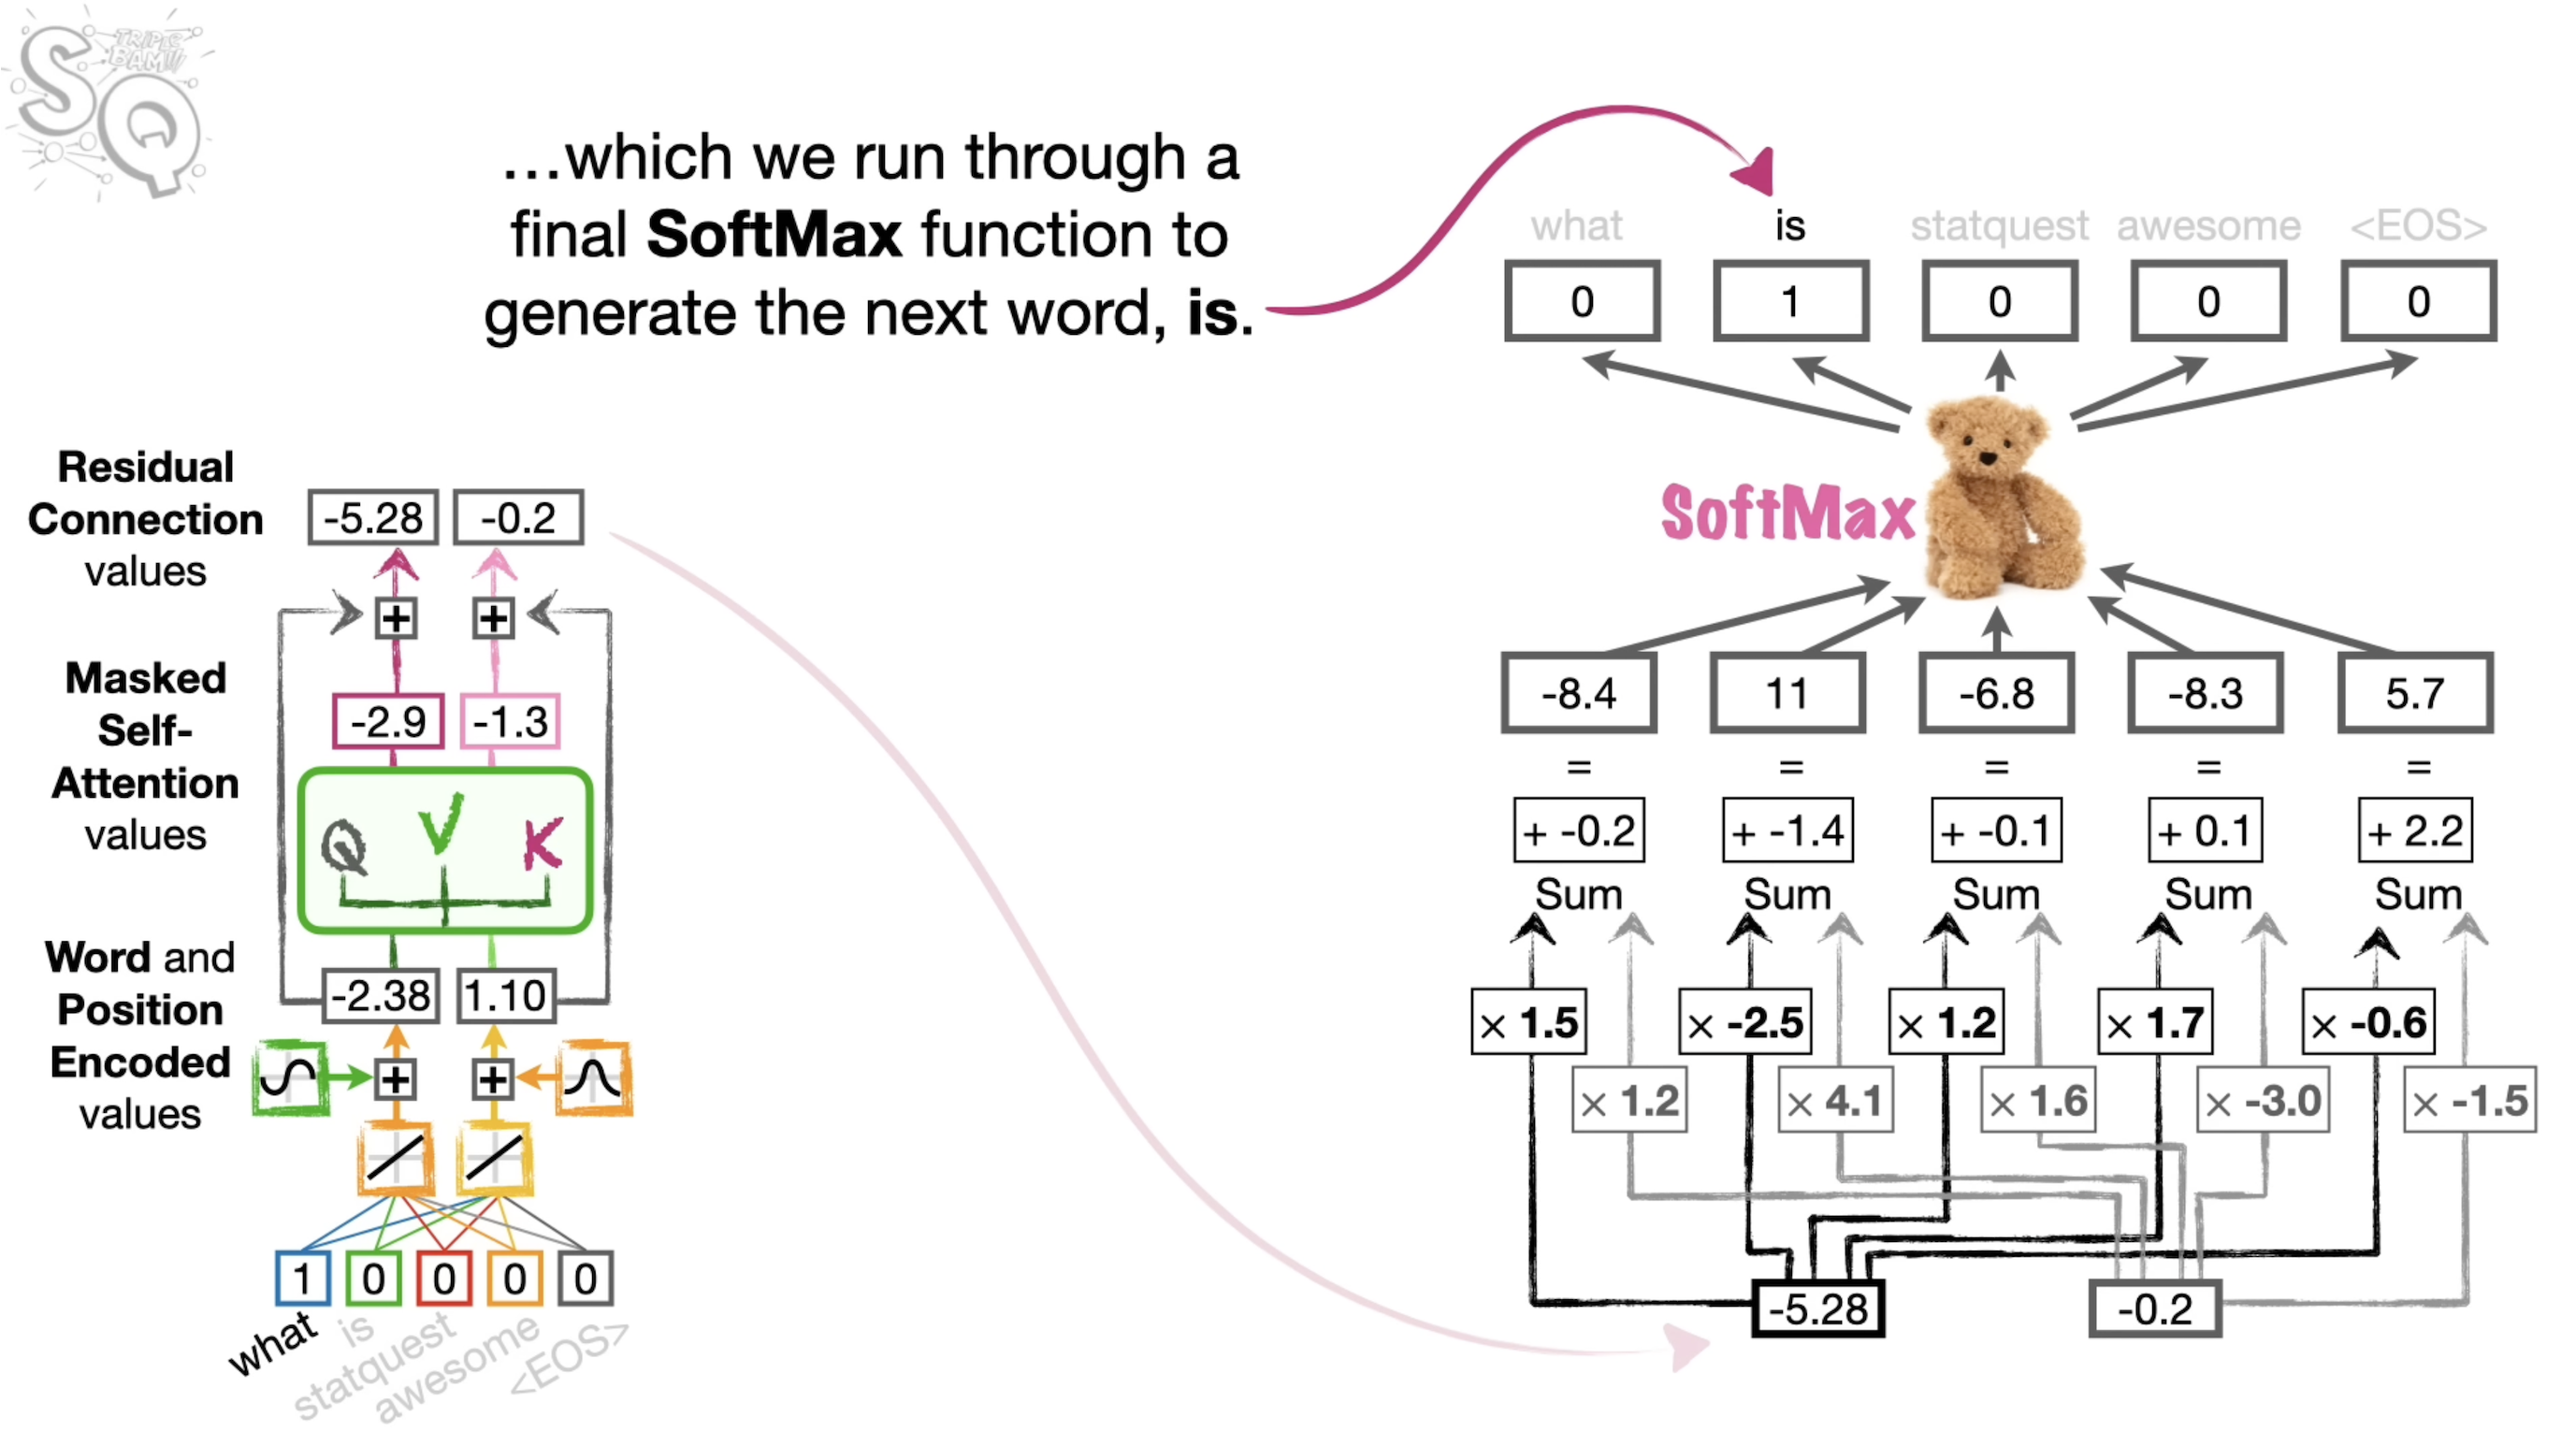

In [20]:
display(Image(filename='./images/resid_connection_1.png', width=900))
display(Image(filename='./images/resid_connection_2.png', width=900))
display(Image(filename='./images/resid_connection_3.png', width=900))

NOTE in the original GPT script, instead the **fully connected network**, they used the Word Embedding networks reverse back to tokens. But using a fully connected network is still a common way.

## All Together in Decoder-only Transformer

![decoder-only_transformer](./images/decoder-only_diagram.png)

A Decoder-Only Transformer simply brings together...

* Word Embedding
* Position Encoding
* Masked Self-Attention
* Residual Connections
* A fully connected layer
* SoftMax - However, the loss function we are using nn.CrossEntropyLoss(), applies the SoftMax for us.

In [16]:

class DecoderOnlyTransformer(L.LightningModule):

    def __init__(self, num_tokens=4, d_model=2, max_len=6):
        
        super().__init__()
        
        L.seed_everything(seed=42)
        
        # NOTE: In this simple example, we are just using a "single layer" decoder.
        #       If we wanted to have multiple layers of decoder, then we would
        #       take the output of one decoder module and use it as input to
        #       the next module.
        
        self.we = nn.Embedding(num_embeddings=num_tokens, embedding_dim=d_model) # we: word embedding 
        self.pe = PositionEncoding(d_model=d_model, max_len=max_len)             # pe: position encoding

        self.self_attention = Attention(d_model=d_model)                         # masked self-attention
        # NOTE: In this simple example, we are not doing multi-head attention
        # If we wanted to do multi-head attention, we could initailize more Attention objects like this...
        #
        # self.self_attention_2 = Attention(d_model=d_model)
        # self.self_attention_3 = Attention(d_model=d_model)
        #
        # If d_model=2, then using 3 self_attention objects would result in d_model*3 = 6 self-attention values per token, 
        # so we would need to initialize a fully connected layer to reduce the dimension of the self attention values back 
        # down to d_model like this:
        #   self.reduce_attention_dim = nn.Linear(in_features=(num_attention_heads*d_model), out_features=d_model)

        self.fc_layer = nn.Linear(in_features=d_model, out_features=num_tokens)
        self.loss = nn.CrossEntropyLoss()
        

    def forward(self, token_ids):
        """
        For the decoder-only transformer, we need to use 'masked self-attention'
        """

        print("token", token_ids)
        
        word_embeddings = self.we(token_ids)        

        print("word emb", word_embeddings)
        
        position_encoded = self.pe(word_embeddings)

        print("pos enco", position_encoded)
               
        # To create the mask we are creating a matrix where the lower triangle is filled with 0, and everything above the diagonal is filled with 0s.
        mask = torch.tril(torch.ones((token_ids.size(dim=0), token_ids.size(dim=0)), device=self.device))
        mask = mask == 0 # We then replace the 0s above the digaonal, which represent the words we want to be masked out, with "True"
        
        self_attention_values = self.self_attention(position_encoded, # Q
                                                    position_encoded, # K 
                                                    position_encoded, # V
                                                    mask=mask)
        # NOTE: If we were doing multi-head attention, we would
        # calculate the self-attention values with the other attention objects
        # like this...
        #
        # self_attention_values_2 = self.self_attention_2(...)
        # self_attention_values 3 = self.self_attention_3(...)
        # 
        # ...then we would concatenate all the self attention values...
        #
        # all_self_attention_values = torch.cat(self_attention_values_1, ...)
        #
        # ...and then run them through reduce_dim to get back to d_model values per token
        #
        # final_self_attention_values = self.reduce_attention_dim(all_self_attention_values)

        residual_connection_values = position_encoded + self_attention_values
        fc_layer_output = self.fc_layer(residual_connection_values)
        
        return fc_layer_output
    
    
    def configure_optimizers(self): 
        return optim.Adam(self.parameters(), lr=0.1)
    
    
    def training_step(self, batch, batch_idx): 
        input_tokens, labels = batch # collect input
        output = self.forward(input_tokens[0])
        loss = self.loss(output, labels[0])
                    
        return loss


In [17]:

print(token_to_id)

## First, create a model from DecoderOnlyTransformer()
model = DecoderOnlyTransformer(num_tokens=len(token_to_id), d_model=2, max_len=6)

## Now create the input for the transformer...
model_input = torch.tensor([token_to_id["what"], 
                            token_to_id["is"], 
                            token_to_id["statquest"], 
                            token_to_id["<EOS>"]])

print(model_input)

input_length = model_input.size(dim=0)
input_length

Seed set to 42


{'what': 0, 'is': 1, 'statquest': 2, 'awesome': 3, '<EOS>': 4}
tensor([0, 1, 2, 4])


4

In [18]:
model.we, model.pe

(Embedding(5, 2), PositionEncoding())

In [19]:
predictions = model(model_input) 
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
## We'll store predicted_id in an array, predicted_ids, that
## we'll add to each time we predict a new output token.
predicted_ids = predicted_id
model_input, predictions, predicted_ids

token tensor([0, 1, 2, 4])
word emb tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863],
        [ 0.4617,  0.2674]], grad_fn=<EmbeddingBackward0>)
pos enco tensor([[ 0.3367,  1.1288],
        [ 1.0759,  0.7706],
        [-0.2136, -0.6025],
        [ 0.6028, -0.7226]], grad_fn=<AddBackward0>)


(tensor([0, 1, 2, 4]),
 tensor([[ 0.1416,  1.0208,  0.7418, -0.4908,  0.1990],
         [ 0.6305,  0.8153,  0.8407, -0.4216,  0.3690],
         [-0.0478,  0.4782,  0.0031, -0.2110,  0.4307],
         [ 0.4689,  0.2814,  0.1306, -0.1480,  0.6007]],
        grad_fn=<AddmmBackward0>),
 tensor([4]))

In [24]:
## Now use a loop to predict output tokens until we get an 
## <EOS> token.
max_length = 6
for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]): # if the prediction is <EOS>, then we are done
        break
    
    model_input = torch.cat((model_input, predicted_id))
    predictions = model(model_input) 

    print(model_input, predictions)
    
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
    predicted_ids = torch.cat((predicted_ids, predicted_id))
        
## Now printout the predicted output phrase.
print("Predicted Tokens:\n") 
for id in predicted_ids: 
    print("\t", id_to_token[id.item()])

Predicted Tokens:

	 <EOS>


## Train the Decoder-Only Transformer

In [31]:
trainer = L.Trainer(max_epochs=30)
trainer.fit(model, train_dataloaders=dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name           | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we             | Embedding        | 10     | train | 0    
1 | pe             | PositionEncoding | 0      | train | 0    
2 | self_attention | Attention        | 12     | train | 0    
3 | fc_layer       | Linear           | 15     | train | 0    
4 | loss           | CrossEntropyLoss | 0      | train | 0    
--------------------------------------

Epoch 29: 100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 310.46it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 164.77it/s, v_num=1]


In [33]:
model_input = torch.tensor([token_to_id["what"], 
                            token_to_id["is"], 
                            token_to_id["statquest"], 
                            token_to_id["<EOS>"]])
input_length = model_input.size(dim=0)

predictions = model(model_input)
print(predictions)
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
predicted_ids = predicted_id

for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]): # if the prediction is <EOS>, then we are done
        break
    
    model_input = torch.cat((model_input, predicted_id))
    
    predictions = model(model_input) 
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
    predicted_ids = torch.cat((predicted_ids, predicted_id))
        
print("Predicted Tokens:\n") 
for id in predicted_ids: 
    print("\t", id_to_token[id.item()])

tensor([[ -1.8830,   8.1349,  -2.0347,   0.2435,  -3.7685],
        [  8.7359,  -4.9200,   8.6772, -14.2976,   3.3124],
        [  1.1200,  -8.3047,   0.9272,  -0.9402,   7.8231],
        [ -8.8753,   0.2327,  -9.1756,  13.6088,   3.9795]],
       grad_fn=<AddmmBackward0>)
Predicted Tokens:

	 awesome
	 <EOS>


In [34]:
## Now let's ask the other question...
model_input = torch.tensor([token_to_id["statquest"], 
                            token_to_id["is"], 
                            token_to_id["what"], 
                            token_to_id["<EOS>"]])
input_length = model_input.size(dim=0)

predictions = model(model_input) 
predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
predicted_ids = predicted_id

for i in range(input_length, max_length):
    if (predicted_id == token_to_id["<EOS>"]): # if the prediction is <EOS>, then we are done
        break
    
    model_input = torch.cat((model_input, predicted_id))
    
    predictions = model(model_input) 
    predicted_id = torch.tensor([torch.argmax(predictions[-1,:])])
    predicted_ids = torch.cat((predicted_ids, predicted_id))
        
print("Predicted Tokens:\n") 
for id in predicted_ids: 
    print("\t", id_to_token[id.item()])

Predicted Tokens:

	 awesome
	 <EOS>
